In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import gc
import shutil
import cv2
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix,
                             roc_curve, precision_recall_curve, average_precision_score, ConfusionMatrixDisplay)

torch.manual_seed(10)

path_dir = 'Coughvid-COVID-Predictor/COVID_vs_Symp/Data/'

path_img_dir_train = path_dir + "MelSpecs_train_covid_vs_symp"
df_label_train = pd.read_csv(path_dir + "MelSpecs_labels_train_covid_vs_symp.csv")

path_img_dir_test = path_dir + "MelSpecs_test_covid_vs_symp"
df_label_test= pd.read_csv(path_dir + "MelSpecs_labels_test_covid_vs_symp.csv")

In [ ]:
(train_df, val_df) = train_test_split(df_label_train, test_size=0.1, stratify=df_label_train["label"], random_state=10)

class MelSpectrogramDataset(Dataset):
    def __init__(self, df, img_dir):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        label = self.df.iloc[idx]["label"]
        filename = self.df.iloc[idx]["filename"]

        # Read image
        img_path = os.path.join(self.img_dir, filename)
        img = cv2.imread(img_path)
        img = img.astype(np.float32) / 255.0
        img = img.transpose(2, 0, 1)  # Convert (H, W, C) to (C, H, W)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(label, dtype=torch.float32)


full_train_dataset = MelSpectrogramDataset(df_label_train, path_img_dir_train)
train_dataset = MelSpectrogramDataset(train_df, path_img_dir_train)
val_dataset = MelSpectrogramDataset(val_df, path_img_dir_train)
test_dataset = MelSpectrogramDataset(df_label_test, path_img_dir_test)

BATCH_SIZE = 256

full_train_loader = DataLoader(full_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# Input dimensions
sample_img, _ = train_dataset[0] 
input_dim = sample_img.shape  # (C, H, W)
print("Input shape:", input_dim)

cuda
Input shape: torch.Size([3, 199, 515])


Define the model

In [ ]:
from Models.CNN_LSTM_attention import CNN_LSTM_attention

# Build model
cnn_lstm = CNN_LSTM_attention(input_dim=input_dim).to(device)

# Enable multi-GPU training if more than one GPU is available
if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs")
    cnn_lstm = nn.DataParallel(cnn_lstm)

# Loss, optimiser, scheduler
criterion_cnn_lstm = nn.BCEWithLogitsLoss()
optimizer_cnn_lstm = torch.optim.Adam(cnn_lstm.parameters(), 
                                        lr=1e-3)


Using 2 GPUs


In [ ]:
###### TRAINING
train_accuracies = []
val_accuracies = []
train_loss=[]
val_loss=[]
best_auc = 0.0
epochs_no_improve = 0
EPOCHS = 100
patience = 10
early_stop = False


for e in range(1, EPOCHS+1):
    cnn_lstm_att.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer_cnn_lstm.zero_grad() 

        y_pred_logits = cnn_lstm_att(X_batch).squeeze()
        y_pred_proba = torch.sigmoid(y_pred_logits) 
        label_predicted = (y_pred_proba >= 0.5).int()

        #Loss
        loss = criterion_cnn_lstm(y_pred_logits, y_batch.float()) 
        running_loss += loss.item()

        #Accuracy
        total += y_batch.size(0)
        correct += (label_predicted == y_batch.int()).sum().item() 

        loss.backward() 
        optimizer_cnn_lstm.step()

    train_acc = correct / total
    train_accuracies.append(train_acc)
    train_loss.append(running_loss/len(train_loader))

    # Validation
    cnn_lstm_att.eval()  
    val_correct = 0
    val_total = 0
    val_running_loss = 0.0
    all_val_probs = []
    all_val_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred_logits = cnn_lstm_att(X_batch).squeeze()
            y_pred_proba = torch.sigmoid(y_pred_logits) 
            val_predicted = (y_pred_proba >= 0.5).int() 

            # For AUC calculations
            all_val_probs.extend(y_pred_proba.cpu().numpy())
            all_val_labels.extend(y_batch.cpu().numpy())

            #Loss
            loss = criterion_cnn_lstm(y_pred_logits, y_batch.float()) 
            val_running_loss += loss.item()

            #Accuracy
            val_total += y_batch.size(0)
            val_correct += (val_predicted == y_batch.int()).sum().item() 

    # Calulate AUC for model saving
    val_auc = roc_auc_score(all_val_labels, all_val_probs)
    val_acc = val_correct / val_total
    val_accuracies.append(val_acc)
    val_loss.append(val_running_loss/len(val_loader))

    # Early stopping
    if val_auc > best_auc:
        best_auc = val_auc
        epochs_no_improve = 0
        torch.save(cnn_lstm_att.state_dict(), path_dir + 'best_cnn_lstm_att.pth')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {e}")
            early_stop = True

    if early_stop:
        break

    # Print metrics for current model
    if e%10==0 or e==1 : 
        print(f'Epoch {e+0:03}: | Loss: {running_loss/len(train_loader):.5f} | Acc: {train_acc:.3f} | Validation Accuracy: {val_acc:.3f}')

# Save final model
torch.save(cnn_lstm_att.state_dict(), "/kaggle/working/final_cnn_lstm_att.pth")

In [ ]:
def plot_train_val_accuracy(train_accuracies,val_accuracies, title='Training and Validation Accuracy', y_lims=[0, 1]):
    """
    Plots training and validation accuracy over epochs
    """
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Train Accuracy', color='blue', marker='o')
    plt.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation Accuracy', color='red', marker='s')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(title)
    plt.ylim(y_lims[0], y_lims[1])
    plt.legend()
    plt.grid()
    plt.savefig('/kaggle/working/accuracy.png')

def plot_train_val_loss(train_loss,val_loss, title='Training and Validation Loss'):
    """
    Plots training and validation loss over epochs
    """
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(train_loss) + 1), train_loss, label='Train Loss', color='blue', marker='o')
    plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='red', marker='s')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.savefig('/kaggle/working/loss.png')

# Plot accuracy and loss curves
plot_train_val_accuracy(train_accuracies, val_accuracies)
plot_train_val_loss(train_loss, val_loss)

In [ ]:
####TEST
if isinstance(cnn_lstm_att, nn.DataParallel):
    cnn_lstm_att = cnn_lstm_att.module

cnn_lstm_att.eval()

all_labels = []
all_probs = []

correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        outputs = cnn_lstm_att(x_batch).view(-1) 
        y_pred_proba = torch.sigmoid(outputs)
        label_predicted = (y_pred_proba >= 0.5).int()

        total += y_batch.size(0)
        correct += (label_predicted == y_batch.int()).sum().item()

        all_labels.append(y_batch.int().cpu())
        all_probs.append(y_pred_proba.cpu())
        all_preds.append(label_predicted.cpu())


        
# Convert result lists to arrays
y_test = np.array(all_labels)
y_pred = np.array(all_preds)
y_prob = np.array(all_probs)

# Save arrays
np.save('y_test_tuned.npy', y_test)
np.save('y_pred_tuned.npy', y_pred)
np.save('y_prob_tuned.npy', y_prob)


# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

Test Accuracy: 0.6909
Precision: 0.3475
Recall: 0.375000
F1-Score: 0.3607
AUC: 0.6418


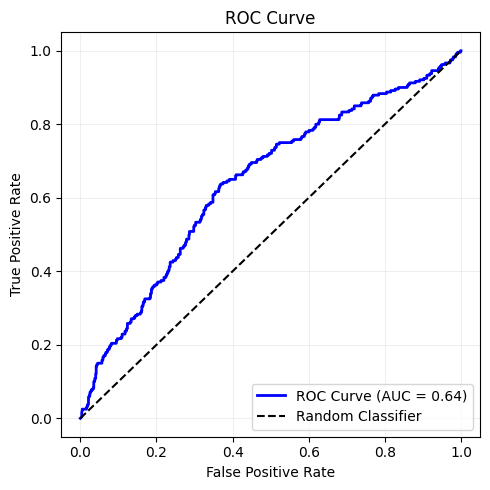

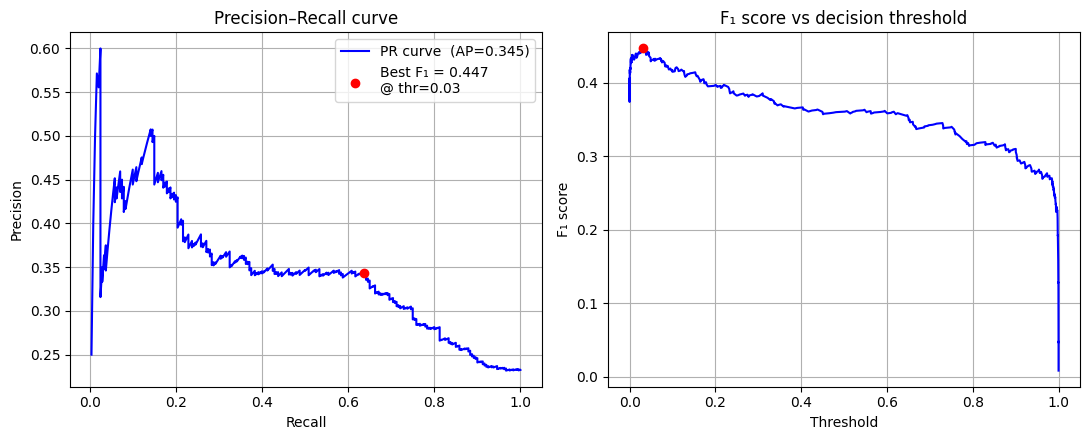

Optimal threshold = 0.032  |  Best F1 = 0.447
Confusion Matrix:
                      Predicted Symptomatic  Predicted COVID
Actually Symptomatic                    500              292
Actually COVID                           87              153

--------------------------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.63      0.73       792
         1.0       0.34      0.64      0.45       240

    accuracy                           0.63      1032
   macro avg       0.60      0.63      0.59      1032
weighted avg       0.73      0.63      0.66      1032

Test Accuracy: 0.6328
Precision: 0.3438
Recall: 0.637500
F1-Score: 0.4467
AUC: 0.6418


In [8]:
def plot_roc_curve(fpr, tpr):
    """
    Plot ROC curve
    """
    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.2f})", color='blue', linewidth=2)
    plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig('/kaggle/working/roc.png')
    plt.show()

def pr_and_f1_curves(y_true, y_prob):
    """
    Plot precision-recall curve and F1 vs threshold curve
    """
    prec, rec, thresh = precision_recall_curve(y_true, y_prob)
    prec, rec = prec[:-1], rec[:-1]
    f1 = 2 * (prec * rec) / (prec + rec + 1e-8)

    best_idx      = np.argmax(f1)
    best_thr      = thresh[best_idx]
    best_f1       = f1[best_idx]
    avg_prec      = average_precision_score(y_true, y_prob)

    fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

    # Left - PR curve
    ax[0].plot(rec, prec, color='blue', label=f'PR curve  (AP={avg_prec:.3f})')
    ax[0].scatter(rec[best_idx], prec[best_idx], color='red', zorder=5,
                  label=f'Best F₁ = {best_f1:.3f}\n@ thr={best_thr:.2f}')
    ax[0].set_xlabel('Recall')
    ax[0].set_ylabel('Precision')
    ax[0].set_title('Precision–Recall curve')
    ax[0].legend()
    ax[0].grid(True)

    # Right - F1 vs threshold
    ax[1].plot(thresh, f1, color='blue')
    ax[1].scatter(best_thr, best_f1, color='red', zorder=5)
    ax[1].set_xlabel('Threshold')
    ax[1].set_ylabel('F₁ score')
    ax[1].set_title('F₁ score vs decision threshold')
    ax[1].grid(True)

    plt.tight_layout()
    plt.savefig('/kaggle/working/pr_f1.png')
    plt.show()

    return best_thr, best_f1
  
# ROC curve
plot_roc_curve(fpr, tpr)

# Plot precision-recall and F1 vs threshold plots
best_thr, best_f1 = pr_and_f1_curves(all_labels, all_probs)
print(f"Optimal threshold = {best_thr:.3f}  |  Best F1 = {best_f1:.3f}")

# Change threshold to maximise F1 score
final_preds = (np.array(all_probs) >= best_thr).astype(int)

# New confusion matrix
cm = confusion_matrix(y_test, final_preds)
confusion_df = pd.DataFrame(cm,
                            index = ['Actually Symptomatic', 'Actually COVID'],
                            columns = ['Predicted Symptomatic', 'Predicted COVID'])
print("Confusion Matrix:")
print(confusion_df)
print("\n" + "-"*80 + "\n")

# New classification report
print("Classification Report:")
print(classification_report(y_test, final_preds, zero_division=0))

# Recompute and print metrics
accuracy = accuracy_score(y_test, final_preds)
precision = precision_score(y_test, final_preds, zero_division=0)
recall = recall_score(y_test, final_preds, zero_division=0)
f1 = f1_score(y_test, final_preds, zero_division=0)
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")